# classification train test

Educational experiment. See [the repository README](README.md) for setup, scope and attribution. Synthetic examples illustrate an algorithm; they do not establish real-world performance.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold

In [2]:
np.random.seed(0) # for reproducibility

In [3]:
#Dogs: higher ear flappiness index, lower whisker length
dogs_whisker_length = np.random.normal(loc=5, scale=1, size=10)
dogs_ear_flappiness_index = np.random.normal(loc=8, scale=1, size=10)

In [4]:
#cats: lower ear flappiness index, higher whisker length
cats_whisker_length = np.random.normal(loc=8, scale=1, size=10)
cats_ear_flappiness_index = np.random.normal(loc=5, scale=1, size=10)


In [5]:
#Prepare data for algorithm
dogs_data = np.vstack((dogs_whisker_length, dogs_ear_flappiness_index)).T
cats_data = np.vstack((cats_whisker_length, cats_ear_flappiness_index)).T
data = np.vstack((dogs_data, cats_data))
labels = np.hstack((np.zeros(len(dogs_data)), np.ones(len(cats_data))))

In [6]:
#Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42, stratify=labels)

In [7]:
x_test

array([[5.95008842, 9.49407907],
       [7.2408932 , 8.12167502],
       [8.8644362 , 4.11221425],
       [8.04575852, 6.23029068]])

In [8]:
x_train

array([[ 5.4105985 ,  7.14590426],
       [ 4.02272212,  8.33367433],
       [ 5.44701018,  5.15494743],
       [10.26975462,  4.65208785],
       [ 8.6536186 ,  5.37816252],
       [ 7.25783498,  3.01920353],
       [ 9.53277921,  4.61267318],
       [ 6.76405235,  8.14404357],
       [ 4.89678115,  8.3130677 ],
       [ 9.46935877,  4.69769725],
       [ 7.81281615,  6.20237985],
       [ 5.97873798,  8.76103773],
       [ 6.54563433,  5.15634897],
       [ 6.86755799,  8.44386323],
       [ 5.40015721,  9.45427351],
       [ 4.84864279,  7.79484174]])

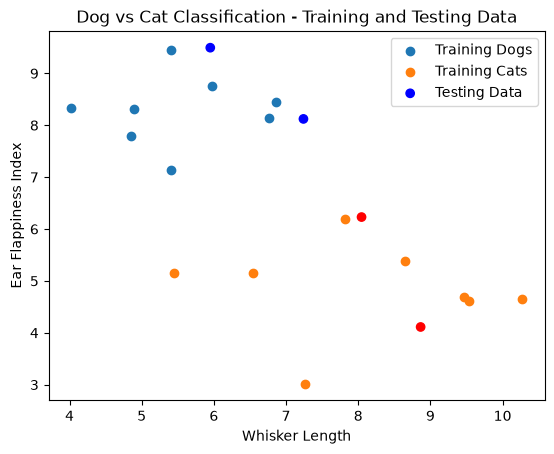

In [9]:
#Plot the training and testing data points
plt.scatter(x_train[y_train == 0][:, 0], x_train[y_train == 0][:, 1], label='Training Dogs')
plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:, 1], label='Training Cats')
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap='bwr', label='Testing Data')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Dog vs Cat Classification - Training and Testing Data')
plt.legend()
plt.show()


In [10]:
#implementing random linear classifier algorithm
def random_linear_classifier(data_dogs, data_cats, k, d):
    best_error = float('inf')
    best_theta = None
    best_theta0 = None

    for _ in range(k):
        theta = np.random.normal(size=d)
        theta0 = np.random.normal()

        error = compute_error(data_dogs, data_cats, theta, theta0)

        if error < best_error:
            best_error = error
            best_theta = theta
            best_theta0 = theta0

    return best_theta, best_theta0, best_error

def compute_error(data_dogs, data_cats, theta, theta0):
    error = 0
    for x_dog in data_dogs:
        if np.dot(theta, x_dog) + theta0 <= 0:
            error += 1
    for x_cat in data_cats:
        if np.dot(theta, x_cat) + theta0 > 0:
            error += 1
    return error

In [11]:
#Run random linear classifier algo on training data
k = 100 # number of iterations
#k = best_k
d = 2 # Number of features
best_theta_train, best_theta0_train, train_error = random_linear_classifier(x_train[y_train == 0], x_train[y_train == 1], k, d)

In [12]:
#plot the decision boundary on training data
x_vals_train = np.linspace(2, 10, 100)
y_vals_train = (-best_theta_train[0] / best_theta_train[1]) * x_vals_train - (best_theta0_train / best_theta_train[1])

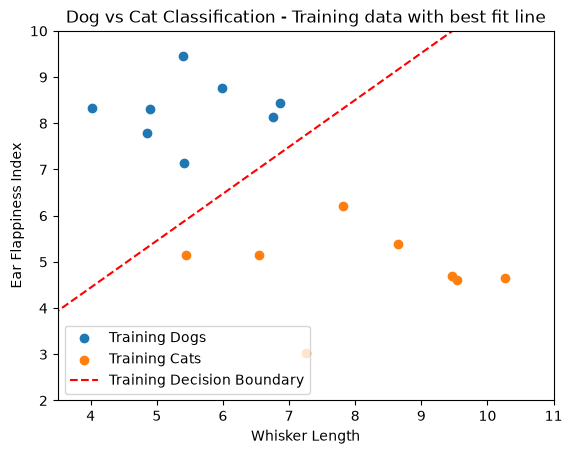

In [13]:
plt.scatter(x_train[y_train == 0][:, 0], x_train[y_train == 0][:, 1], label='Training Dogs')
plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:, 1], label='Training Cats')
plt.plot(x_vals_train, y_vals_train, color='red', linestyle='--', label='Training Decision Boundary')
#Set same limits for x and y axes
plt.xlim([3.5, 11])
plt.ylim([2,10])
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Dog vs Cat Classification - Training data with best fit line')
plt.legend()
plt.show()

In [14]:
# compute_error treats dogs as positive scores; labels encode dogs as 0.
train_predictions = np.where(x_train @ best_theta_train + best_theta0_train > 0, 0, 1)
test_predictions = np.where(x_test @ best_theta_train + best_theta0_train > 0, 0, 1)
for name,truth,predictions in [('train',y_train,train_predictions),('test',y_test,test_predictions)]:
    correct = int(np.sum(truth == predictions))
    print(f'{name}: {correct}/{len(truth)} correct; accuracy={correct/len(truth):.3f}')


train: 16/16 correct; accuracy=1.000
test: 4/4 correct; accuracy=1.000


The test split has only four synthetic examples. Each mistake changes accuracy by 25 percentage points. This demonstrates held-out evaluation, not a reliable estimate of generalisation.
